In [1]:
# ── CELL 1: Install (run once, then restart kernel) ─────────────
!pip install healpy numpy scipy matplotlib --break-system-packages


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── CELL 2: Imports ─────────────────────────────────────────────
import numpy as np
import healpy as hp
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

In [3]:
# ── CELL 3: Load Data ───────────────────────────────────────────
data     = np.load("sakshum_lmax_sample.npz")
tec_maps = data["tec"]           # (206, 71, 73)  raw TEC in TECU
lats     = data["lats"]          # (71,)  87.5 → -87.5  descending
lons     = data["lons"]          # (73,) -180 → 180
symh     = data["day_min_symh"]  # (206,)  SYM-H storm indicator in nT

print(f"Maps            : {tec_maps.shape[0]}")
print(f"Lat grid        : {lats[0]:.1f} → {lats[-1]:.1f}  (2.5°, {len(lats)} pts)")
print(f"Lon grid        : {lons[0]:.1f} → {lons[-1]:.1f}  (5.0°, {len(lons)} pts)")
print(f"SYM-H range     : {symh.min():.0f} to {symh.max():.0f} nT")
print(f"Storm maps (< -100 nT) : {(symh < -100).sum()}")
print(f"Quiet maps (>  -50 nT) : {(symh > -50).sum()}")

Maps            : 206
Lat grid        : 87.5 → -87.5  (2.5°, 71 pts)
Lon grid        : -180.0 → 180.0  (5.0°, 73 pts)
SYM-H range     : -488 to -27 nT
Storm maps (< -100 nT) : 13
Quiet maps (>  -50 nT) : 129


In [4]:
# ── CELL 4: Subtract Area-Weighted Spatial Mean ─────────────────
# Approximates IRI subtraction: removes the global mean (l=0–1
# structure) so the residual has faster spectral decay.
# Replace with actual IRI residual once Hayden's pipeline is ready.

cos_w     = np.cos(np.radians(lats))
area_w    = cos_w[:, None] * np.ones(len(lons))
area_w   /= area_w.sum()
smean     = (tec_maps * area_w[None]).sum(axis=(1, 2), keepdims=True)
tec_resid = tec_maps - smean                       # (206, 71, 73)

print(f"Residual range: {tec_resid.min():.2f} → {tec_resid.max():.2f} TECU")

Residual range: -37.02 → 128.82 TECU


In [5]:
# ── CELL 5: Compute S_l for Every Map ───────────────────────────
# Pipeline per map:
#   1. Interpolate (71×73) lat/lon → HEALPix sphere
#   2. SHT: healpy.map2alm → f̂_lm
#   3. C_l = healpy.alm2cl(alm)   [= 1/(2l+1) · Σ_m |f̂_lm|²]
#   4. S_l = (2l+1) · C_l         [=            Σ_m |f̂_lm|²]
#
# S_l is what appears in the theorem:  ‖f − f_L‖² = Σ_{l>L} S_l
# so truncation error IS the tail of this spectrum.

NSIDE    = 64     # HEALPix resolution, ~0.9° pixels
LMAX_CAP = 36     # grid Nyquist for 2.5° lat spacing

npix             = hp.nside2npix(NSIDE)
hp_theta, hp_phi = hp.pix2ang(NSIDE, np.arange(npix))
hp_lat           = 90.0 - np.degrees(hp_theta)
hp_lon           = np.degrees(hp_phi)
hp_lon[hp_lon > 180] -= 360
query_pts        = np.column_stack([hp_lat, hp_lon])
lats_asc         = lats[::-1]          # ascending for interpolator

S_l_all = np.zeros((len(tec_resid), LMAX_CAP + 1))

for i, tec_map in enumerate(tec_resid):
    interp     = RegularGridInterpolator(
        (lats_asc, lons), tec_map[::-1],
        method="linear", bounds_error=False, fill_value=0.0
    )
    hp_map     = interp(query_pts)
    alm        = hp.map2alm(hp_map, lmax=LMAX_CAP)
    cl         = hp.alm2cl(alm)
    ell        = np.arange(len(cl))
    S_l_all[i] = (2 * ell + 1) * cl

print(f"S_l computed. Shape: {S_l_all.shape}")

S_l computed. Shape: (206, 37)


In [6]:
# ── CELL 6: Mean Spectra + L_max ────────────────────────────────
storm_mask = symh < -100
quiet_mask = symh > -50

S_l_mean  = S_l_all.mean(axis=0)
S_l_quiet = S_l_all[quiet_mask].mean(axis=0)
S_l_storm = S_l_all[storm_mask].mean(axis=0)
ell       = np.arange(LMAX_CAP + 1)
E_total   = S_l_mean.sum()
cumulative = np.cumsum(S_l_mean)
frac_captured = cumulative / E_total

# ── Criterion A: Parseval energy bound ──────────────────────────
# Smallest L s.t.  Σ_{l>L} S_l  ≤  ε · E_total
epsilon   = 0.001       # retain 99.9% of signal energy
L_max_A   = int(np.argmax(frac_captured >= 1 - epsilon))

# ── Criterion B: cliff detection ────────────────────────────────
# The IONEX product is built by fitting SH up to l=15 internally.
# This produces a hard cliff in S_l, not a gradual decay.
# We detect it as the first l where log10(S_l) drops > 1.5 decades
# from the previous degree — a ×30+ sudden drop.
# Note: even-l values at l≥16 are elevated by aliasing from the 5°
# longitude grid (artifact, not real signal); cliff detection is
# robust to this because the drop at l=16 is ×160, far exceeding
# the 1.5-decade threshold.
log_S   = np.log10(S_l_mean + 1e-12)
drops   = np.diff(log_S)                           # shape (LMAX_CAP,)
cliffs  = np.where(drops < -1.5)[0]               # l values where cliff hits
L_max_B = int(cliffs[0]) if len(cliffs) else LMAX_CAP

# ── Final answer ────────────────────────────────────────────────
L_max = max(L_max_A, L_max_B)
N_lat = L_max + 1          # minimum Gauss-Legendre latitude points
N_lon = 2 * L_max + 1      # minimum longitude points for exact DFT

# Noise floor (for display only): odd-l tail is pure noise
sigma2 = S_l_mean[17::2].mean()   # odd l from 17–35, free of aliasing

print()
print(f"{'l':>3}  {'S_l':>10}  {'cumul %':>9}  {'note'}")
print("-" * 52)
for l in range(LMAX_CAP + 1):
    note = ""
    if l == L_max:   note = f"← L_max  ({frac_captured[l]*100:.3f}% energy)"
    if l == L_max+1: note = "← cliff here  (×{:.0f} drop)".format(
                                S_l_mean[l-1]/max(S_l_mean[l],1e-12))
    print(f"{l:>3}  {S_l_mean[l]:>10.4f}  {frac_captured[l]*100:>8.3f}%  {note}")

print()
print("=" * 55)
print(f"  Criterion A  (99.9% energy, ε={epsilon})  : {L_max_A}")
print(f"  Criterion B  (cliff detection)           : {L_max_B}")
print(f"  → Final L_max                            : {L_max}")
print(f"  → N_lat  (Gauss-Legendre)                : {N_lat}")
print(f"  → N_lon  (≥ 2·L_max+1)                  : {N_lon}")
print(f"  Tail error Σ_{{l>{L_max}}} S_l             : {E_total-cumulative[L_max]:.5f}")
print(f"  = {(1-frac_captured[L_max])*100:.4f}% of E_total  ✓")
print("=" * 55)



  l         S_l    cumul %  note
----------------------------------------------------
  0      0.2349     0.007%  
  1   1540.9363    48.690%  
  2   1021.4125    80.960%  
  3    166.8169    86.230%  
  4    164.4429    91.425%  
  5     69.7426    93.628%  
  6     36.8011    94.791%  
  7     26.4096    95.625%  
  8     21.4682    96.304%  
  9     20.6189    96.955%  
 10     16.6106    97.480%  
 11     18.5389    98.066%  
 12     20.3972    98.710%  
 13     16.7237    99.238%  
 14     12.8728    99.645%  
 15     10.3182    99.971%  ← L_max  (99.971% energy)
 16      0.0637    99.973%  ← cliff here  (×162 drop)
 17      0.0090    99.973%  
 18      0.0670    99.975%  
 19      0.0089    99.976%  
 20      0.0713    99.978%  
 21      0.0088    99.978%  
 22      0.0738    99.981%  
 23      0.0088    99.981%  
 24      0.0777    99.983%  
 25      0.0091    99.984%  
 26      0.0790    99.986%  
 27      0.0089    99.986%  
 28      0.0798    99.989%  
 29      0.0093    99.

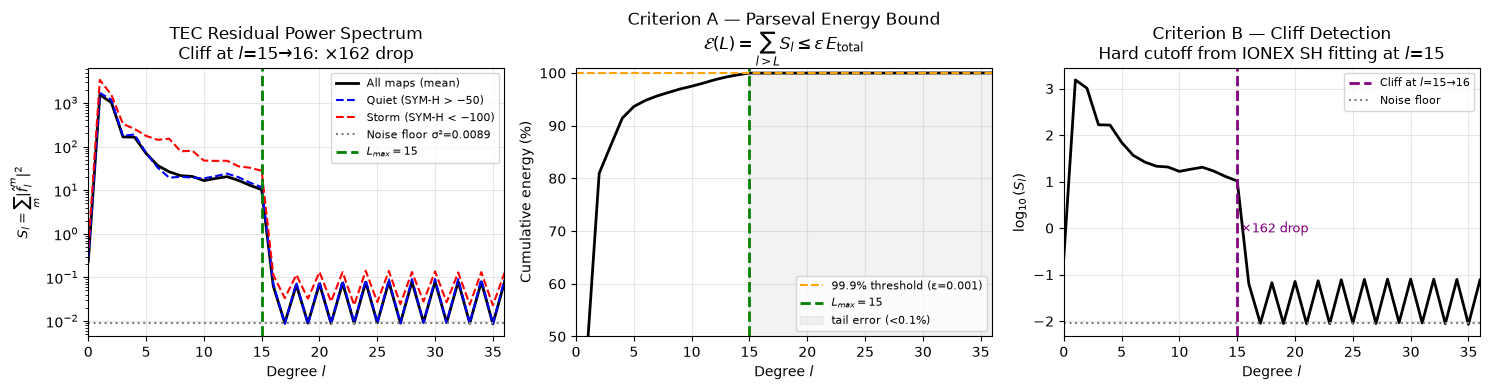

Saved: lmax_power_spectrum.png


In [7]:
# ── CELL 7: Plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — power spectra
ax = axes[0]
ax.semilogy(ell, S_l_mean,  "k-",  lw=2,   label="All maps (mean)")
ax.semilogy(ell, S_l_quiet, "b--", lw=1.5, label="Quiet (SYM-H > −50)")
ax.semilogy(ell, S_l_storm, "r--", lw=1.5, label="Storm (SYM-H < −100)")
ax.axhline(sigma2, color="gray", ls=":", label=f"Noise floor σ²={sigma2:.4f}")
ax.axvline(L_max, color="green", ls="--", lw=2, label=f"$L_{{max}}={L_max}$")
ax.set_xlabel("Degree $l$")
ax.set_ylabel("$S_l = \\sum_m |\\hat{f}_l^m|^2$")
ax.set_title("TEC Residual Power Spectrum\n"
             f"Cliff at $l$={L_max}→{L_max+1}: ×"
             f"{S_l_mean[L_max]/S_l_mean[L_max+1]:.0f} drop")
ax.legend(fontsize=8); ax.set_xlim(0, LMAX_CAP); ax.grid(True, alpha=0.3)

# Plot 2 — cumulative energy (Criterion A)
ax = axes[1]
ax.plot(ell, frac_captured * 100, "k-", lw=2)
ax.axhline((1-epsilon)*100, color="orange", ls="--",
           label=f"{(1-epsilon)*100:.1f}% threshold (ε={epsilon})")
ax.axvline(L_max_A, color="green", ls="--", lw=2,
           label=f"$L_{{max}}={L_max_A}$")
ax.fill_between(ell[L_max_A:], 0, frac_captured[L_max_A:]*100,
                alpha=0.1, color="gray", label="tail error (<0.1%)")
ax.set_xlabel("Degree $l$")
ax.set_ylabel("Cumulative energy (%)")
ax.set_title("Criterion A — Parseval Energy Bound\n"
             r"$\mathcal{E}(L)=\sum_{l>L}S_l \leq \varepsilon\,E_{\rm total}$")
ax.legend(fontsize=8); ax.set_xlim(0, LMAX_CAP)
ax.set_ylim(50, 101); ax.grid(True, alpha=0.3)

# Plot 3 — log S_l with cliff visible (Criterion B)
ax = axes[2]
ax.plot(ell, np.log10(S_l_mean + 1e-12), "k-", lw=2)
ax.axvline(L_max_B, color="purple", ls="--", lw=2,
           label=f"Cliff at $l$={L_max_B}→{L_max_B+1}")
ax.axhline(np.log10(sigma2), color="gray", ls=":", label="Noise floor")
ax.annotate(f"×{S_l_mean[L_max_B]/S_l_mean[L_max_B+1]:.0f} drop",
            xy=(L_max_B+0.3, (np.log10(S_l_mean[L_max_B])+np.log10(S_l_mean[L_max_B+1]))/2),
            fontsize=9, color="purple")
ax.set_xlabel("Degree $l$")
ax.set_ylabel("$\\log_{10}(S_l)$")
ax.set_title("Criterion B — Cliff Detection\n"
             "Hard cutoff from IONEX SH fitting at $l$=15")
ax.legend(fontsize=8); ax.set_xlim(0, LMAX_CAP); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lmax_power_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lmax_power_spectrum.png")

In [8]:
# ── CELL 8: Send to Team ─────────────────────────────────────────
print()
print("=" * 55)
print("  FOR FALISHA AND HAYDEN")
print("=" * 55)
print(f"""
Quadrature : Gauss-Legendre  (not equiangular, not Lebedev)
  Reason: GL integrates degree-(2N-1) polynomials exactly with
  N points. Equiangular needs 2× more points for same accuracy.

L_max = {L_max}
N_lat = {N_lat}   (= L_max + 1)
N_lon = {N_lon}  (= 2·L_max + 1)

Evidence (two independent criteria, same answer):
  A) Parseval energy: {frac_captured[L_max]*100:.3f}% of signal energy
     is at l ≤ {L_max}. Tail error = {(1-frac_captured[L_max])*100:.4f}% < ε=0.1%.
  B) Cliff detection: S_l drops ×{S_l_mean[L_max]/S_l_mean[L_max+1]:.0f}
     between l={L_max} and l={L_max+1}. This is because CODE
     builds IONEX by fitting SH internally up to l=15.

Note on even-l aliasing (l=16,18,...,36):
  These appear elevated (~0.07) vs odd-l noise (~0.009) due
  to aliasing from the 5° longitude sampling when interpolating
  to HEALPix. These are artifacts, not real signal.

Falisha: torch-harmonics call →  lmax={L_max}, nlat={N_lat}, nlon={N_lon}
Hayden:  IRI residual will have same or smaller L_max.
         This is a conservative upper bound from raw TEC.
""")



  FOR FALISHA AND HAYDEN

Quadrature : Gauss-Legendre  (not equiangular, not Lebedev)
  Reason: GL integrates degree-(2N-1) polynomials exactly with
  N points. Equiangular needs 2× more points for same accuracy.

L_max = 15
N_lat = 16   (= L_max + 1)
N_lon = 31  (= 2·L_max + 1)

Evidence (two independent criteria, same answer):
  A) Parseval energy: 99.971% of signal energy
     is at l ≤ 15. Tail error = 0.0290% < ε=0.1%.
  B) Cliff detection: S_l drops ×162
     between l=15 and l=16. This is because CODE
     builds IONEX by fitting SH internally up to l=15.

Note on even-l aliasing (l=16,18,...,36):
  These appear elevated (~0.07) vs odd-l noise (~0.009) due
  to aliasing from the 5° longitude sampling when interpolating
  to HEALPix. These are artifacts, not real signal.

Falisha: torch-harmonics call →  lmax=15, nlat=16, nlon=31
Hayden:  IRI residual will have same or smaller L_max.
         This is a conservative upper bound from raw TEC.

